# Model Experiments on Balanced Normalized Data (n = 1918)

This notebook runs all classification models on the GAN-augmented balanced normalized dataset.

## Models:
1. Random Forest Classifier
2. Gradient Boosting Classifier
3. XGBoost Classifier
4. CatBoost Classifier
5. Logistic Regression
6. Artificial Neural Network (PyTorch)

## Target: Current_CGPA5 (5 classes)
- Class 0 (normalized: 0.0) = CGPA 3.6-4.0
- Class 1 (normalized: 0.25) = CGPA 3.2-3.59
- Class 2 (normalized: 0.5) = CGPA 2.8-3.19
- Class 3 (normalized: 0.75) = CGPA 2.4-2.79
- Class 4 (normalized: 1.0) = CGPA <2.4

## 1. Import Libraries

In [32]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Deep Learning - PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Train-Test Split and Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score, roc_auc_score, precision_score, recall_score
)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("All libraries imported successfully!")

Using device: cuda
All libraries imported successfully!


## 2. Load Balanced Normalized Data

In [33]:
# Load the GAN-augmented balanced normalized data
df = pd.read_csv(r'../data/Final_Combined_Normalized.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset Shape: (1918, 31)

Columns: ['Age', 'Gender', 'Where_live', 'AVG_Sleep_Per_Night', 'Regular_Bed_time', 'Exam_Night_Bed_Time', 'Holiday_Bed_Time', 'Regular_WakeUp_Time', 'Holiday_WakeUp_Time', 'Have_Regular_Bed_Time', 'Daytime_Nap', 'Struggle_to_Sleep', 'Sleep_Condition', 'Electronic_Devices_Before_Bed', 'Consume_Caffeine_Night', 'Dinnar_Time', 'Smoke', 'Sleep_Affecting_Drugs', 'Daily_Academics_Time_Spend', 'Main_Reason_for_Insufficient_Sleep', 'Rate_Sleep_Quality', 'Class_Attendance', 'Sleepiness_During_Class', 'Skip_Class_for_Sleep', 'Focus_on_Academic_Task', 'Impact_of_Sleep_on_Academic', 'Current_CGPA5', 'CGPA3_Class', 'Aware_of_Recomamended_Sleep', 'Use_Sleep_Tracking_Devices', 'Sacrifices_Sleep_for_Academics']


,Age,Gender,Where_live,AVG_Sleep_Per_Night,Regular_Bed_time,Exam_Night_Bed_Time,Holiday_Bed_Time,Regular_WakeUp_Time,Holiday_WakeUp_Time,Have_Regular_Bed_Time,...,Class_Attendance,Sleepiness_During_Class,Skip_Class_for_Sleep,Focus_on_Academic_Task,Impact_of_Sleep_on_Academic,Current_CGPA5,CGPA3_Class,Aware_of_Recomamended_Sleep,Use_Sleep_Tracking_Devices,Sacrifices_Sleep_for_Academics
0,0.666667,1.0,0.0,1.000000,1.00,1.00,1.00,1.0,1.0,0.0,...,0.333333,0.666667,0.0,0.0,0.75,0.50,0.5,1.0,0.0,1.0
1,0.666667,0.0,0.5,0.333333,0.75,0.25,0.25,0.5,1.0,0.0,...,0.333333,0.000000,1.0,0.5,0.75,0.75,0.5,1.0,0.0,1.0
2,0.666667,0.0,0.5,0.000000,1.00,1.00,1.00,0.5,1.0,0.0,...,0.000000,0.000000,1.0,0.0,0.00,0.75,0.5,1.0,0.0,1.0
3,1.000000,0.0,0.5,0.666667,0.50,0.75,1.00,0.5,1.0,0.0,...,0.000000,0.000000,0.0,1.0,0.25,0.75,0.5,1.0,0.0,1.0
4,0.666667,0.0,0.0,0.333333,0.75,0.75,0.75,0.5,0.5,0.0,...,1.000000,0.333333,0.0,0.5,0.25,0.75,0.5,0.0,0.0,1.0


In [34]:
# Check class distribution
TARGET_COLUMN = 'Current_CGPA5'

print("Class Distribution (Normalized Values):")
print(df[TARGET_COLUMN].value_counts().sort_index())

# Convert normalized target back to integer classes for modeling
# 0.0 -> 0, 0.25 -> 1, 0.5 -> 2, 0.75 -> 3, 1.0 -> 4
df['Target'] = (df[TARGET_COLUMN] * 4).round().astype(int)

print("\nConverted Target Classes:")
print(df['Target'].value_counts().sort_index())
print("\n0 = CGPA 3.6-4.0 (Excellent)")
print("1 = CGPA 3.2-3.59 (Very Good)")
print("2 = CGPA 2.8-3.19 (Good)")
print("3 = CGPA 2.4-2.79 (Satisfactory)")
print("4 = CGPA <2.4 (Poor)")

Class Distribution (Normalized Values):
Current_CGPA5
0.00    309
0.25    346
0.50    315
0.75    293
1.00    655
Name: count, dtype: int64

Converted Target Classes:
Target
0    309
1    346
2    315
3    293
4    655
Name: count, dtype: int64

0 = CGPA 3.6-4.0 (Excellent)
1 = CGPA 3.2-3.59 (Very Good)
2 = CGPA 2.8-3.19 (Good)
3 = CGPA 2.4-2.79 (Satisfactory)
4 = CGPA <2.4 (Poor)


## 3. Prepare Features and Target

In [35]:
# Define features (exclude target columns)
exclude_cols = ['CGPA3_Class', 'Target', 'Current_CGPA5']  # Exclude target and related columns
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Number of features: 29
Features: ['Age', 'Gender', 'Where_live', 'AVG_Sleep_Per_Night', 'Regular_Bed_time', 'Exam_Night_Bed_Time', 'Holiday_Bed_Time', 'Regular_WakeUp_Time', 'Holiday_WakeUp_Time', 'Have_Regular_Bed_Time', 'Daytime_Nap', 'Struggle_to_Sleep', 'Sleep_Condition', 'Electronic_Devices_Before_Bed', 'Consume_Caffeine_Night', 'Dinnar_Time', 'Smoke', 'Sleep_Affecting_Drugs', 'Daily_Academics_Time_Spend', 'Main_Reason_for_Insufficient_Sleep', 'Rate_Sleep_Quality', 'Class_Attendance', 'Sleepiness_During_Class', 'Skip_Class_for_Sleep', 'Focus_on_Academic_Task', 'Impact_of_Sleep_on_Academic', 'Aware_of_Recomamended_Sleep', 'Use_Sleep_Tracking_Devices', 'Sacrifices_Sleep_for_Academics']


In [36]:
# Prepare X and y
X = df[feature_cols].values
y = df['Target'].values

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({c/len(y_train)*100:.1f}%)")

print(f"\nTest class distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({c/len(y_test)*100:.1f}%)")

Training set: 1534 samples
Test set: 384 samples

Training class distribution:
  Class 0: 247 (16.1%)
  Class 1: 277 (18.1%)
  Class 2: 252 (16.4%)
  Class 3: 234 (15.3%)
  Class 4: 524 (34.2%)

Test class distribution:
  Class 0: 62 (16.1%)
  Class 1: 69 (18.0%)
  Class 2: 63 (16.4%)
  Class 3: 59 (15.4%)
  Class 4: 131 (34.1%)


## 4. Helper Functions

In [37]:
# Store all results
all_results = []

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate model and return metrics
    """
    y_pred = model.predict(X_test)
    
    # For models that support predict_proba
    try:
        y_prob = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    except:
        roc_auc = None
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    
    result = {
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'Macro F1-Score': round(macro_f1, 4),
        'Balanced Accuracy': round(balanced_acc, 4),
        'ROC-AUC': round(roc_auc, 4) if roc_auc else 'N/A'
    }
    
    all_results.append(result)
    return result, y_pred

def plot_confusion_matrix(y_test, y_pred, model_name):
    """
    Plot confusion matrix
    """
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    class_labels = ['Excellent\n(3.6-4.0)', 'Very Good\n(3.2-3.59)', 'Good\n(2.8-3.19)', 
                    'Satisfactory\n(2.4-2.79)', 'Poor\n(<2.4)']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels,
                yticklabels=class_labels)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

def print_classification_report(y_test, y_pred, model_name):
    """
    Print classification report
    """
    print(f"\n{'='*60}")
    print(f"Classification Report - {model_name}")
    print('='*60)
    print(classification_report(y_test, y_pred, 
          target_names=['Excellent (3.6-4.0)', 'Very Good (3.2-3.59)', 'Good (2.8-3.19)', 
                        'Satisfactory (2.4-2.79)', 'Poor (<2.4)']))

---
## 5. Model 1: Random Forest Classifier

In [38]:
print("Training Random Forest Classifier...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
result, y_pred_rf = evaluate_model(rf_model, X_test, y_test, 'Random Forest')

print(f"\nResults:")
for key, value in result.items():
    print(f"  {key}: {value}")

Training Random Forest Classifier...

Results:
  Model: Random Forest
  Accuracy: 0.4427
  Macro F1-Score: 0.3363
  Balanced Accuracy: 0.3529
  ROC-AUC: 0.7162


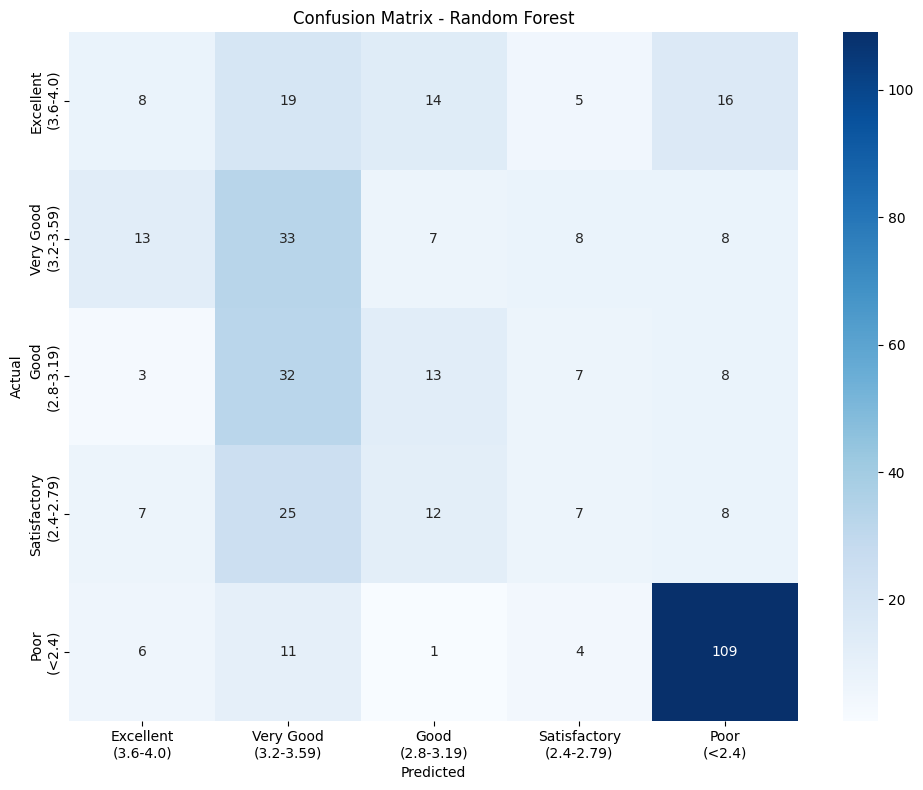


Classification Report - Random Forest
                         precision    recall  f1-score   support

    Excellent (3.6-4.0)       0.22      0.13      0.16        62
   Very Good (3.2-3.59)       0.28      0.48      0.35        69
        Good (2.8-3.19)       0.28      0.21      0.24        63
Satisfactory (2.4-2.79)       0.23      0.12      0.16        59
            Poor (<2.4)       0.73      0.83      0.78       131

               accuracy                           0.44       384
              macro avg       0.35      0.35      0.34       384
           weighted avg       0.41      0.44      0.42       384



In [39]:
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')
print_classification_report(y_test, y_pred_rf, 'Random Forest')

---
## 6. Model 2: Gradient Boosting Classifier

In [40]:
print("Training Gradient Boosting Classifier...")

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,
    max_features='sqrt',
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

gb_model.fit(X_train, y_train)
result, y_pred_gb = evaluate_model(gb_model, X_test, y_test, 'Gradient Boosting')

print(f"\nResults:")
for key, value in result.items():
    print(f"  {key}: {value}")

Training Gradient Boosting Classifier...

Results:
  Model: Gradient Boosting
  Accuracy: 0.4479
  Macro F1-Score: 0.3532
  Balanced Accuracy: 0.3581
  ROC-AUC: 0.7267


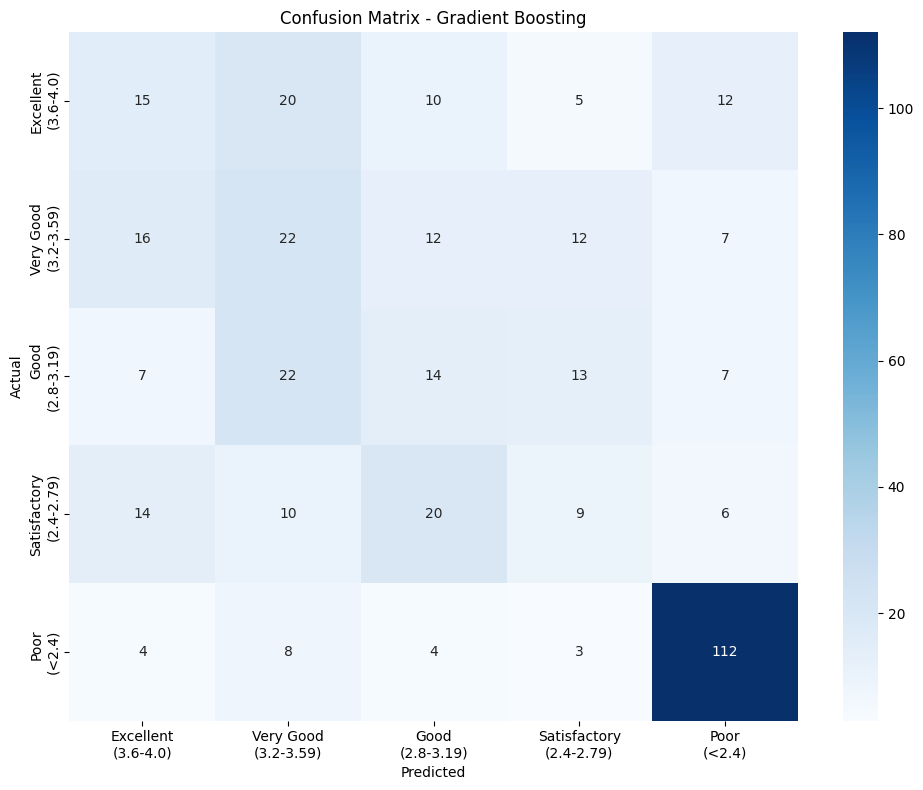


Classification Report - Gradient Boosting
                         precision    recall  f1-score   support

    Excellent (3.6-4.0)       0.27      0.24      0.25        62
   Very Good (3.2-3.59)       0.27      0.32      0.29        69
        Good (2.8-3.19)       0.23      0.22      0.23        63
Satisfactory (2.4-2.79)       0.21      0.15      0.18        59
            Poor (<2.4)       0.78      0.85      0.81       131

               accuracy                           0.45       384
              macro avg       0.35      0.36      0.35       384
           weighted avg       0.43      0.45      0.44       384



In [41]:
plot_confusion_matrix(y_test, y_pred_gb, 'Gradient Boosting')
print_classification_report(y_test, y_pred_gb, 'Gradient Boosting')

---
## 7. Model 3: XGBoost Classifier

In [42]:
print("Training XGBoost Classifier...")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)
result, y_pred_xgb = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')

print(f"\nResults:")
for key, value in result.items():
    print(f"  {key}: {value}")

Training XGBoost Classifier...

Results:
  Model: XGBoost
  Accuracy: 0.4531
  Macro F1-Score: 0.3711
  Balanced Accuracy: 0.3734
  ROC-AUC: 0.7249


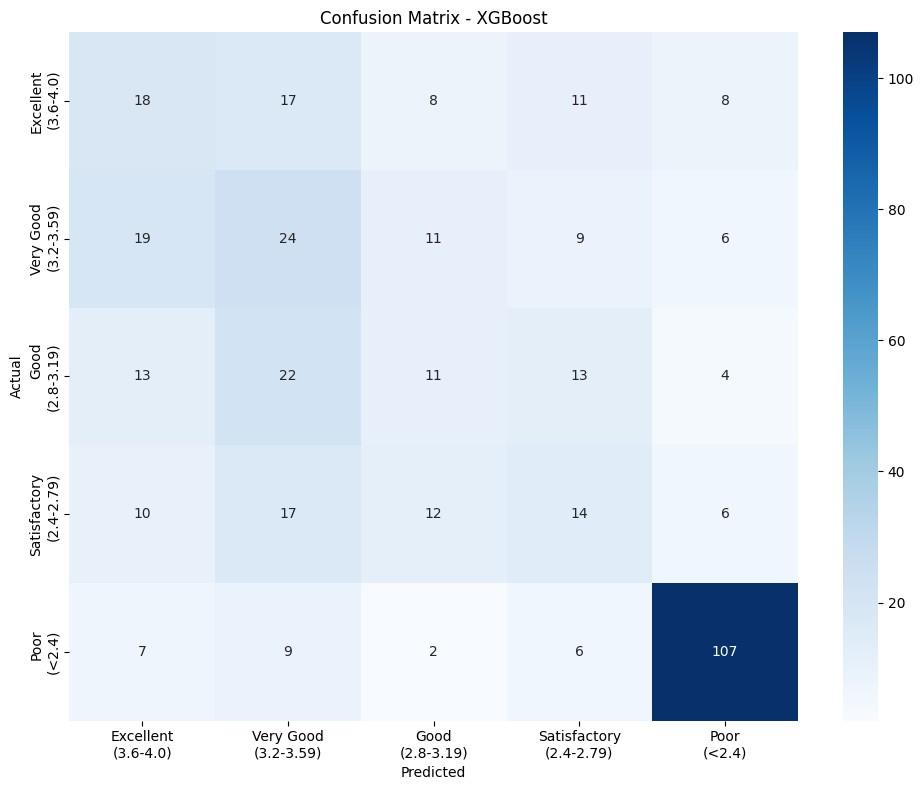


Classification Report - XGBoost
                         precision    recall  f1-score   support

    Excellent (3.6-4.0)       0.27      0.29      0.28        62
   Very Good (3.2-3.59)       0.27      0.35      0.30        69
        Good (2.8-3.19)       0.25      0.17      0.21        63
Satisfactory (2.4-2.79)       0.26      0.24      0.25        59
            Poor (<2.4)       0.82      0.82      0.82       131

               accuracy                           0.45       384
              macro avg       0.37      0.37      0.37       384
           weighted avg       0.45      0.45      0.45       384



In [43]:
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost')
print_classification_report(y_test, y_pred_xgb, 'XGBoost')

---
## 8. Model 4: CatBoost Classifier

In [44]:
print("Training CatBoost Classifier...")

catboost_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=False
)

catboost_model.fit(X_train, y_train)
result, y_pred_cat = evaluate_model(catboost_model, X_test, y_test, 'CatBoost')

print(f"\nResults:")
for key, value in result.items():
    print(f"  {key}: {value}")

Training CatBoost Classifier...

Results:
  Model: CatBoost
  Accuracy: 0.4661
  Macro F1-Score: 0.3731
  Balanced Accuracy: 0.3797
  ROC-AUC: 0.7289


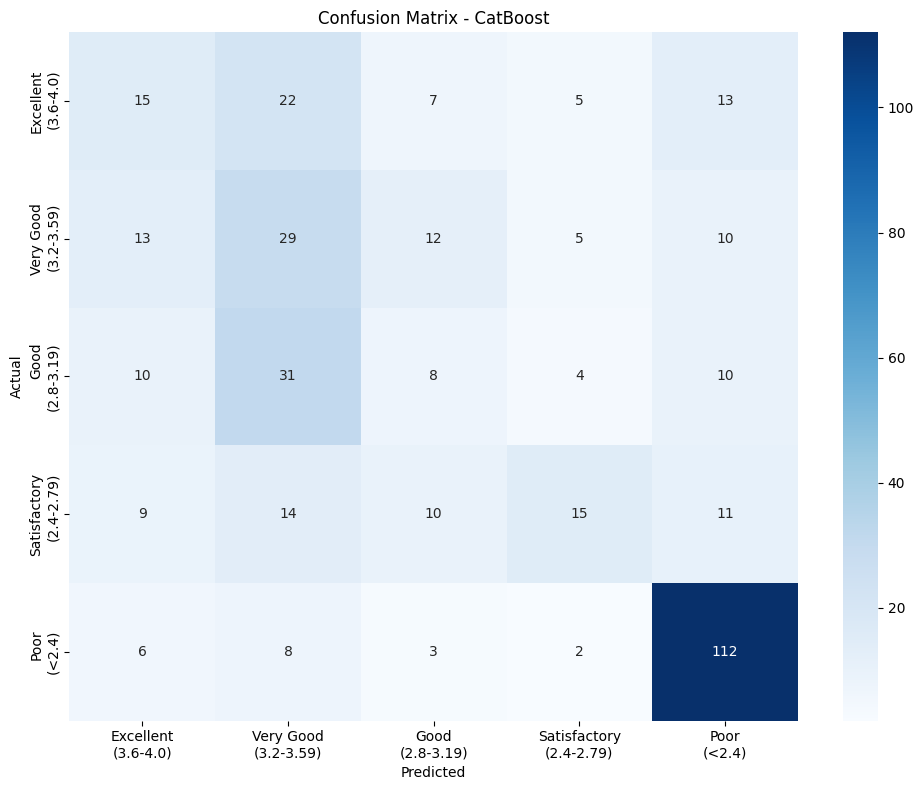


Classification Report - CatBoost
                         precision    recall  f1-score   support

    Excellent (3.6-4.0)       0.28      0.24      0.26        62
   Very Good (3.2-3.59)       0.28      0.42      0.34        69
        Good (2.8-3.19)       0.20      0.13      0.16        63
Satisfactory (2.4-2.79)       0.48      0.25      0.33        59
            Poor (<2.4)       0.72      0.85      0.78       131

               accuracy                           0.47       384
              macro avg       0.39      0.38      0.37       384
           weighted avg       0.45      0.47      0.45       384



In [45]:
plot_confusion_matrix(y_test, y_pred_cat, 'CatBoost')
print_classification_report(y_test, y_pred_cat, 'CatBoost')

---
## 9. Model 5: Logistic Regression

In [46]:
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=2000,
    C=0.5,
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    multi_class='multinomial',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train, y_train)
result, y_pred_lr = evaluate_model(lr_model, X_test, y_test, 'Logistic Regression')

print(f"\nResults:")
for key, value in result.items():
    print(f"  {key}: {value}")

Training Logistic Regression...

Results:
  Model: Logistic Regression
  Accuracy: 0.4141
  Macro F1-Score: 0.3432
  Balanced Accuracy: 0.3454
  ROC-AUC: 0.6648


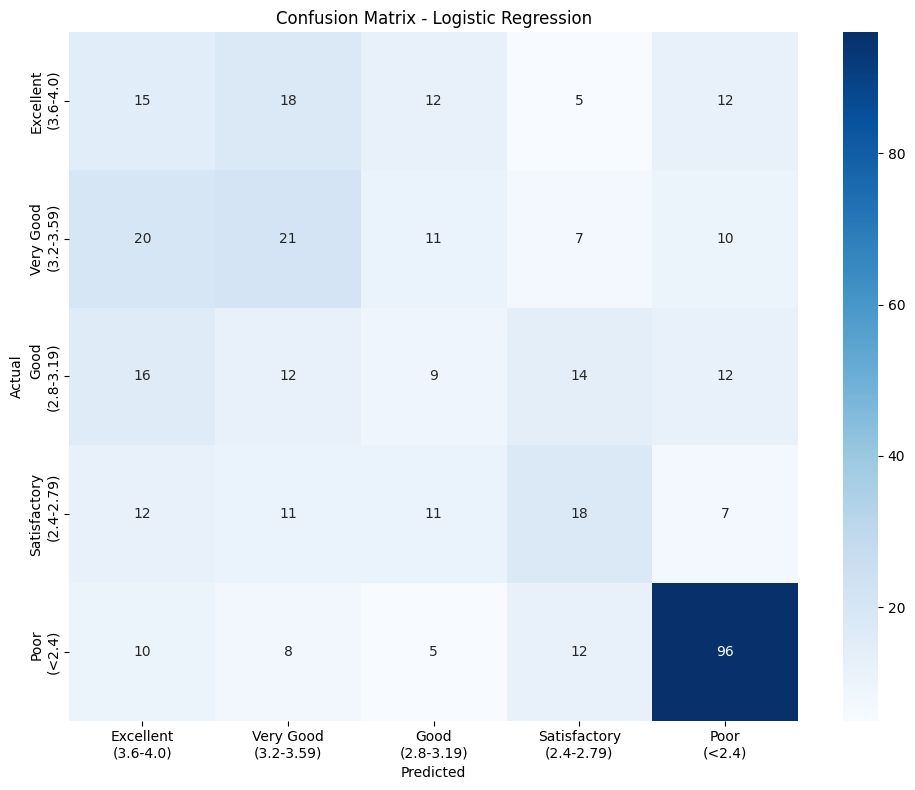


Classification Report - Logistic Regression
                         precision    recall  f1-score   support

    Excellent (3.6-4.0)       0.21      0.24      0.22        62
   Very Good (3.2-3.59)       0.30      0.30      0.30        69
        Good (2.8-3.19)       0.19      0.14      0.16        63
Satisfactory (2.4-2.79)       0.32      0.31      0.31        59
            Poor (<2.4)       0.70      0.73      0.72       131

               accuracy                           0.41       384
              macro avg       0.34      0.35      0.34       384
           weighted avg       0.41      0.41      0.41       384



In [47]:
plot_confusion_matrix(y_test, y_pred_lr, 'Logistic Regression')
print_classification_report(y_test, y_pred_lr, 'Logistic Regression')

---
## 10. Model 6: Artificial Neural Network (PyTorch)

In [48]:
# Define Neural Network Architecture
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes):
        super(NeuralNetwork, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

print("Neural Network class defined.")

Neural Network class defined.


In [49]:
# Prepare data for PyTorch
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Initialize model
input_size = X_train.shape[1]
hidden_sizes = [128, 64, 32]
num_classes = 5  # 5 classes for Current_CGPA5

ann_model = NeuralNetwork(input_size, hidden_sizes, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ann_model.parameters(), lr=0.001)

print(f"Model architecture:")
print(ann_model)

Model architecture:
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=29, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=5, bias=True)
  )
)


In [50]:
# Training loop
print("Training Neural Network...")
epochs = 100
train_losses = []

for epoch in range(epochs):
    ann_model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = ann_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    train_losses.append(epoch_loss / len(train_loader))
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_losses[-1]:.4f}")

print("\nTraining completed!")

Training Neural Network...
Epoch [20/100], Loss: 1.2722
Epoch [40/100], Loss: 1.1778
Epoch [60/100], Loss: 1.0945
Epoch [80/100], Loss: 1.0110
Epoch [100/100], Loss: 0.9540

Training completed!


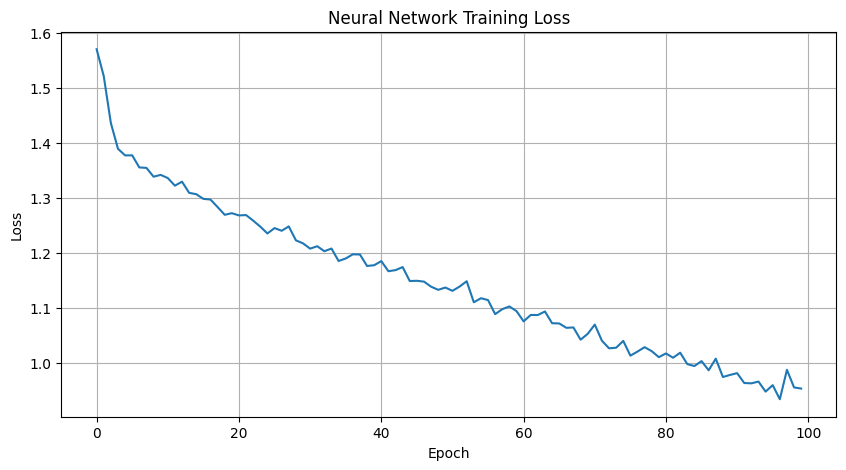

In [51]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Neural Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [52]:
# Evaluate Neural Network
ann_model.eval()
with torch.no_grad():
    outputs = ann_model(X_test_tensor)
    _, y_pred_ann = torch.max(outputs, 1)
    y_pred_ann = y_pred_ann.cpu().numpy()
    
    # Get probabilities for ROC-AUC
    y_prob_ann = torch.softmax(outputs, dim=1).cpu().numpy()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_ann)
macro_f1 = f1_score(y_test, y_pred_ann, average='macro')
balanced_acc = balanced_accuracy_score(y_test, y_pred_ann)
roc_auc = roc_auc_score(y_test, y_prob_ann, multi_class='ovr', average='macro')

result = {
    'Model': 'Neural Network',
    'Accuracy': round(accuracy, 4),
    'Macro F1-Score': round(macro_f1, 4),
    'Balanced Accuracy': round(balanced_acc, 4),
    'ROC-AUC': round(roc_auc, 4)
}
all_results.append(result)

print(f"\nNeural Network Results:")
for key, value in result.items():
    print(f"  {key}: {value}")


Neural Network Results:
  Model: Neural Network
  Accuracy: 0.4036
  Macro F1-Score: 0.3282
  Balanced Accuracy: 0.3314
  ROC-AUC: 0.6928


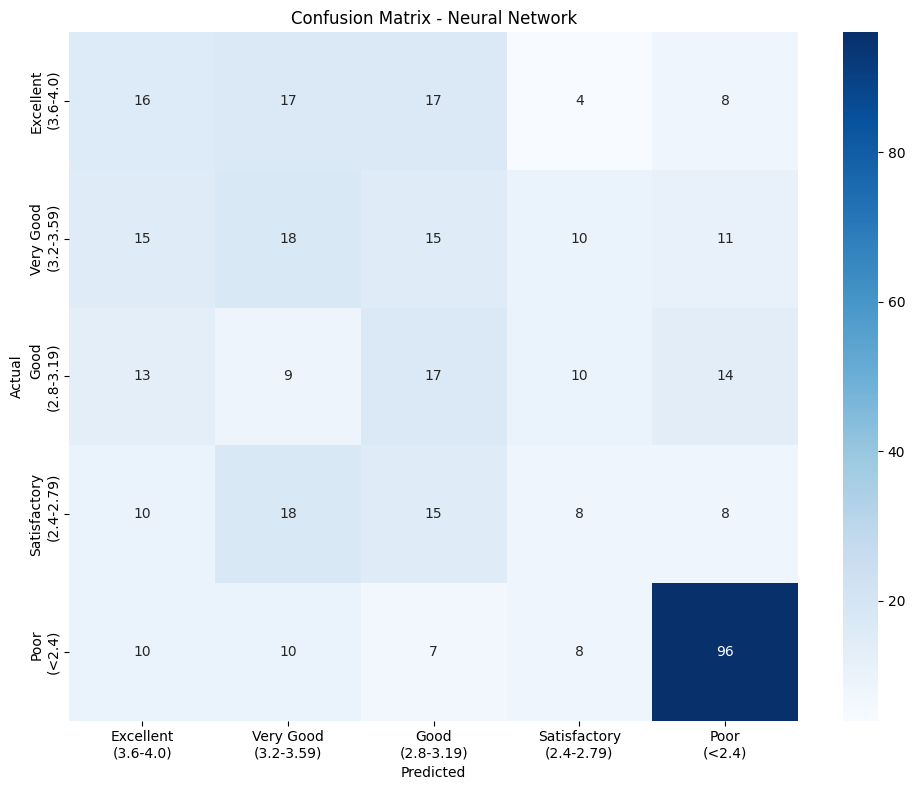


Classification Report - Neural Network
                         precision    recall  f1-score   support

    Excellent (3.6-4.0)       0.25      0.26      0.25        62
   Very Good (3.2-3.59)       0.25      0.26      0.26        69
        Good (2.8-3.19)       0.24      0.27      0.25        63
Satisfactory (2.4-2.79)       0.20      0.14      0.16        59
            Poor (<2.4)       0.70      0.73      0.72       131

               accuracy                           0.40       384
              macro avg       0.33      0.33      0.33       384
           weighted avg       0.39      0.40      0.40       384



In [53]:
plot_confusion_matrix(y_test, y_pred_ann, 'Neural Network')
print_classification_report(y_test, y_pred_ann, 'Neural Network')

---
## 11. Model Comparison

In [54]:
# Create comparison dataframe
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("="*80)
print("MODEL COMPARISON - 5-Class CGPA Prediction (Current_CGPA5)")
print("="*80)
print(results_df.to_string(index=False))

MODEL COMPARISON - 5-Class CGPA Prediction (Current_CGPA5)
              Model  Accuracy  Macro F1-Score  Balanced Accuracy  ROC-AUC
           CatBoost    0.4661          0.3731             0.3797   0.7289
            XGBoost    0.4531          0.3711             0.3734   0.7249
  Gradient Boosting    0.4479          0.3532             0.3581   0.7267
      Random Forest    0.4427          0.3363             0.3529   0.7162
Logistic Regression    0.4141          0.3432             0.3454   0.6648
     Neural Network    0.4036          0.3282             0.3314   0.6928


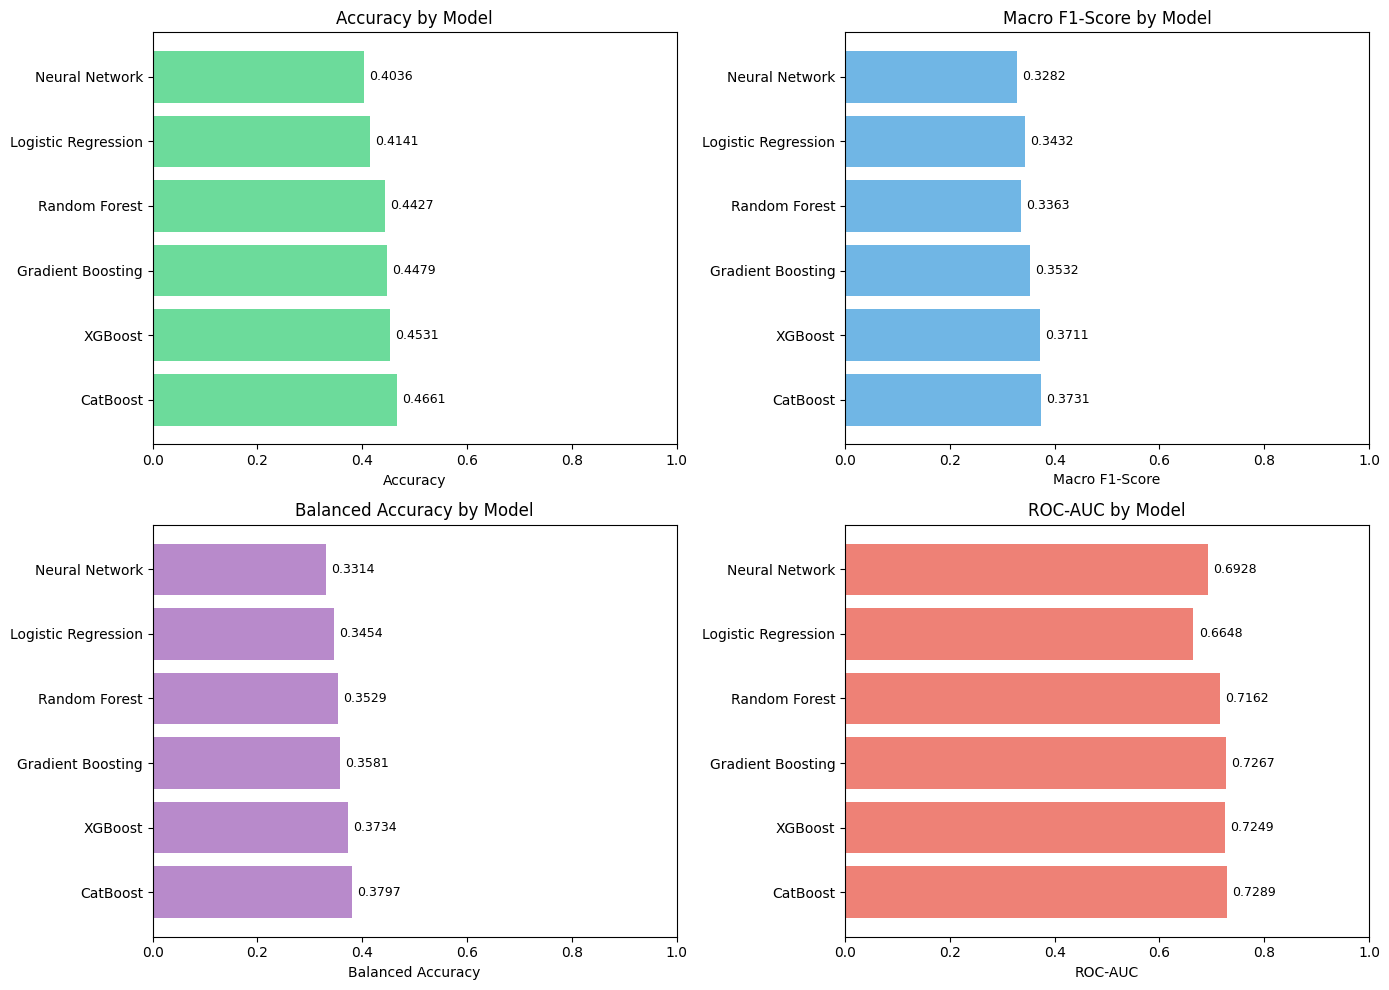


Figure saved to: ../images/model_comparison_5class_cgpa.png


In [55]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Macro F1-Score', 'Balanced Accuracy', 'ROC-AUC']
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

for idx, (ax, metric, color) in enumerate(zip(axes.flat, metrics, colors)):
    if metric == 'ROC-AUC':
        # Handle 'N/A' values
        plot_df = results_df[results_df['ROC-AUC'] != 'N/A'].copy()
        plot_df['ROC-AUC'] = plot_df['ROC-AUC'].astype(float)
        values = plot_df[metric].values
        models = plot_df['Model'].values
    else:
        values = results_df[metric].values
        models = results_df['Model'].values
    
    bars = ax.barh(models, values, color=color, alpha=0.7)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} by Model')
    ax.set_xlim(0, 1)
    
    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/model_comparison_5class_cgpa.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to: ../images/model_comparison_5class_cgpa.png")

In [56]:
# Save results to CSV
results_df.to_csv('../results/5class_cgpa_model_results.csv', index=False)
print("Results saved to: ../results/5class_cgpa_model_results.csv")
print("\n" + "="*80)
print("EXPERIMENT COMPLETE!")
print("="*80)

Results saved to: ../results/5class_cgpa_model_results.csv

EXPERIMENT COMPLETE!


## 12. Summary

This notebook ran 6 machine learning models on the GAN-augmented balanced normalized dataset:

1. **Random Forest** - Ensemble of decision trees
2. **Gradient Boosting** - Sequential boosting
3. **XGBoost** - Optimized gradient boosting
4. **CatBoost** - Gradient boosting with categorical support
5. **Logistic Regression** - Linear model for classification
6. **Neural Network** - Deep learning with PyTorch

### Key Points:
- Data is already normalized (values between 0 and 1)
- Classes are balanced using GAN-generated synthetic data
- No feature engineering applied - plain model runs
- Target: Current_CGPA5 (5 classes)

---
## 13. Feature Importance Visualization

Visualizing which features contribute most to predictions for each model.

In [57]:
# Get feature importances from tree-based models
feature_importance_dict = {}

# Random Forest
feature_importance_dict['Random Forest'] = rf_model.feature_importances_

# Gradient Boosting
feature_importance_dict['Gradient Boosting'] = gb_model.feature_importances_

# XGBoost
feature_importance_dict['XGBoost'] = xgb_model.feature_importances_

# CatBoost
feature_importance_dict['CatBoost'] = catboost_model.feature_importances_

# Logistic Regression (use absolute coefficients averaged across classes)
lr_importance = np.mean(np.abs(lr_model.coef_), axis=0)
lr_importance = lr_importance / lr_importance.sum()  # Normalize
feature_importance_dict['Logistic Regression'] = lr_importance

print("Feature importances extracted for all models!")

Feature importances extracted for all models!


In [58]:
# Create feature importance dataframe
importance_df = pd.DataFrame(feature_importance_dict, index=feature_cols)
importance_df['Average'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=False)

print("Top 15 Most Important Features (Averaged across models):")
print("="*60)
print(importance_df['Average'].head(15).to_string())
print("\nBottom 5 Least Important Features:")
print(importance_df['Average'].tail(5).to_string())

Top 15 Most Important Features (Averaged across models):
Focus_on_Academic_Task                2.288786
Main_Reason_for_Insufficient_Sleep    2.130381
Sleepiness_During_Class               1.904417
Daily_Academics_Time_Spend            1.374473
Struggle_to_Sleep                     1.340510
Rate_Sleep_Quality                    1.320133
Class_Attendance                      1.281084
Where_live                            1.124673
Age                                   1.024282
Regular_WakeUp_Time                   0.930193
Daytime_Nap                           0.876202
AVG_Sleep_Per_Night                   0.704598
Sleep_Condition                       0.579629
Impact_of_Sleep_on_Academic           0.468048
Exam_Night_Bed_Time                   0.443614

Bottom 5 Least Important Features:
Sacrifices_Sleep_for_Academics    0.137665
Sleep_Affecting_Drugs             0.111947
Skip_Class_for_Sleep              0.103747
Smoke                             0.064002
Electronic_Devices_Before_Bed 

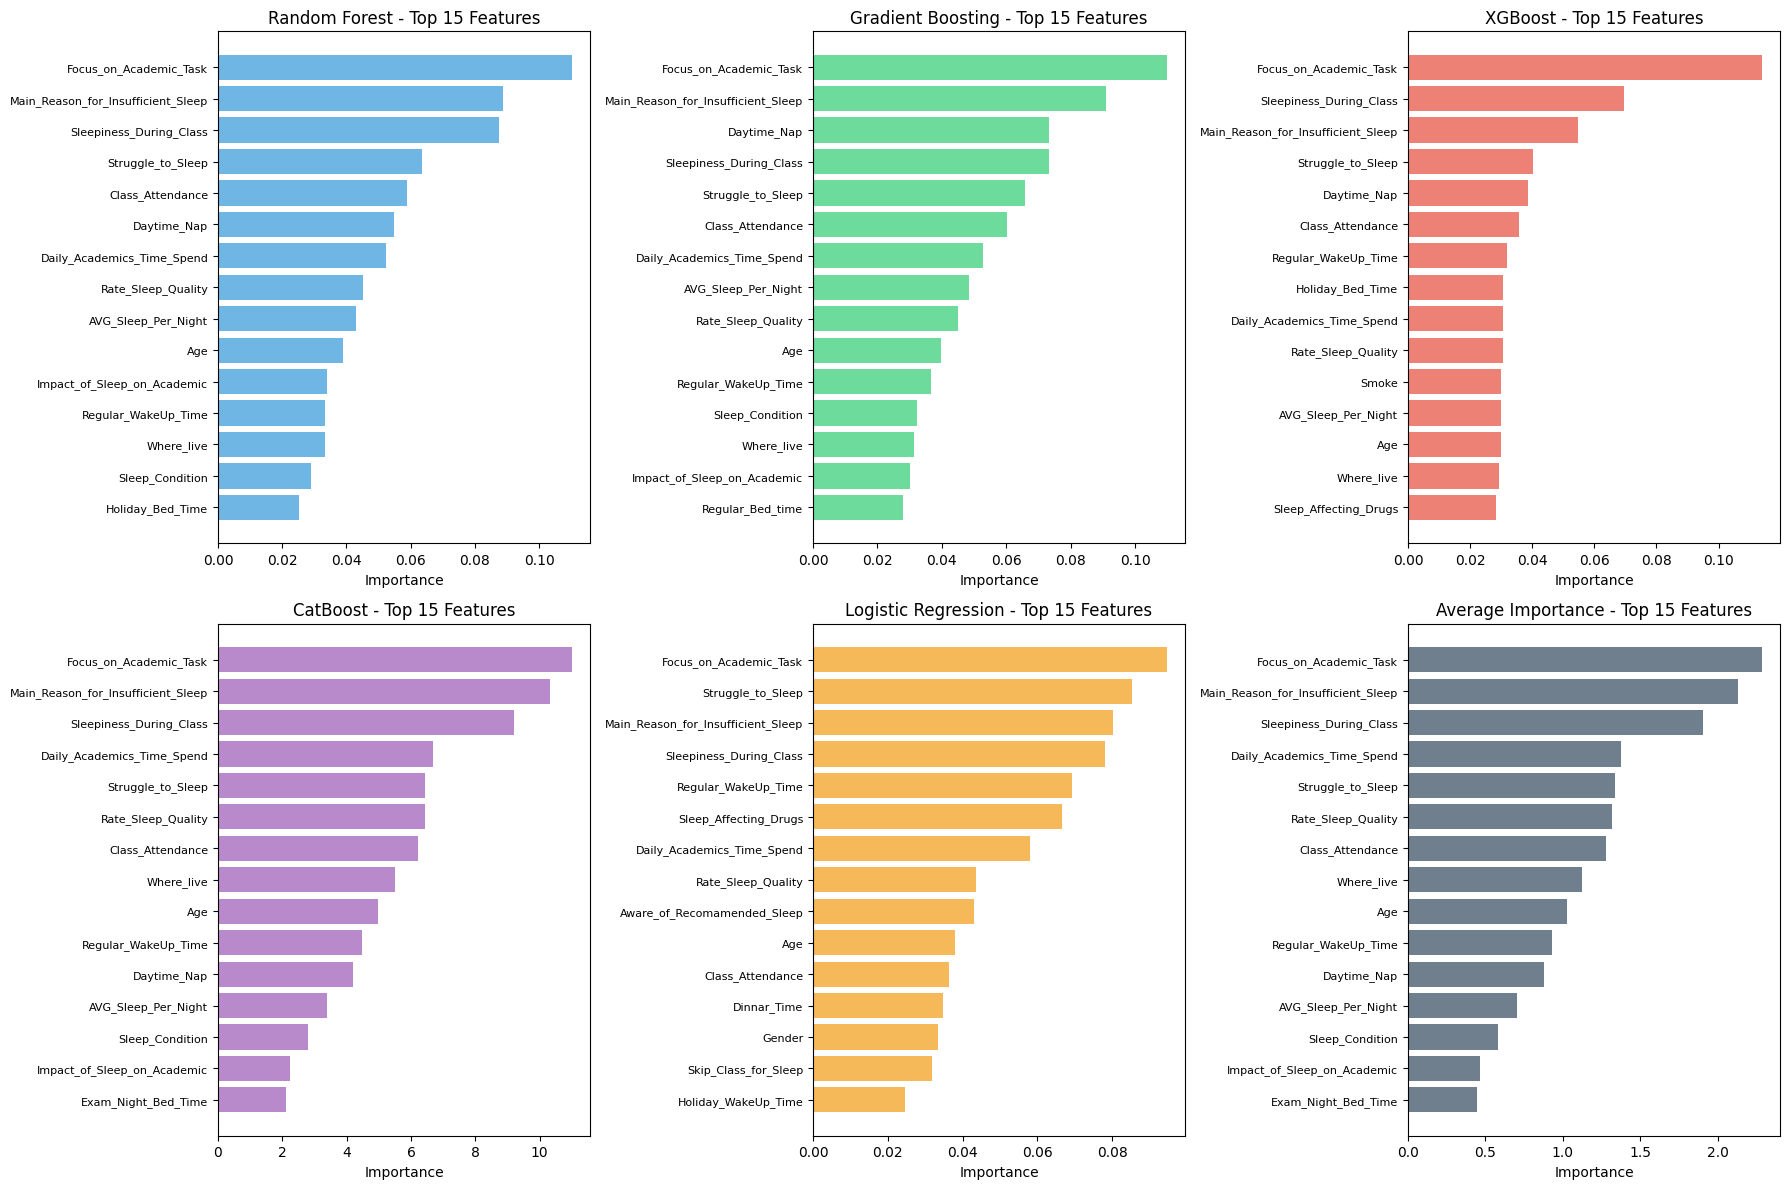


Figure saved to: ../images/feature_importance_5class_all_models.png


In [59]:
# Visualize feature importance for each model
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
models_to_plot = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'CatBoost', 'Logistic Regression']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

for idx, (ax, model_name, color) in enumerate(zip(axes.flat[:5], models_to_plot, colors)):
    # Get top 15 features for this model
    model_importance = importance_df[model_name].sort_values(ascending=True).tail(15)
    
    ax.barh(model_importance.index, model_importance.values, color=color, alpha=0.7)
    ax.set_xlabel('Importance')
    ax.set_title(f'{model_name} - Top 15 Features')
    ax.tick_params(axis='y', labelsize=8)

# Average importance in the last subplot
ax = axes.flat[5]
avg_importance = importance_df['Average'].sort_values(ascending=True).tail(15)
ax.barh(avg_importance.index, avg_importance.values, color='#34495e', alpha=0.7)
ax.set_xlabel('Importance')
ax.set_title('Average Importance - Top 15 Features')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../images/feature_importance_5class_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to: ../images/feature_importance_5class_all_models.png")

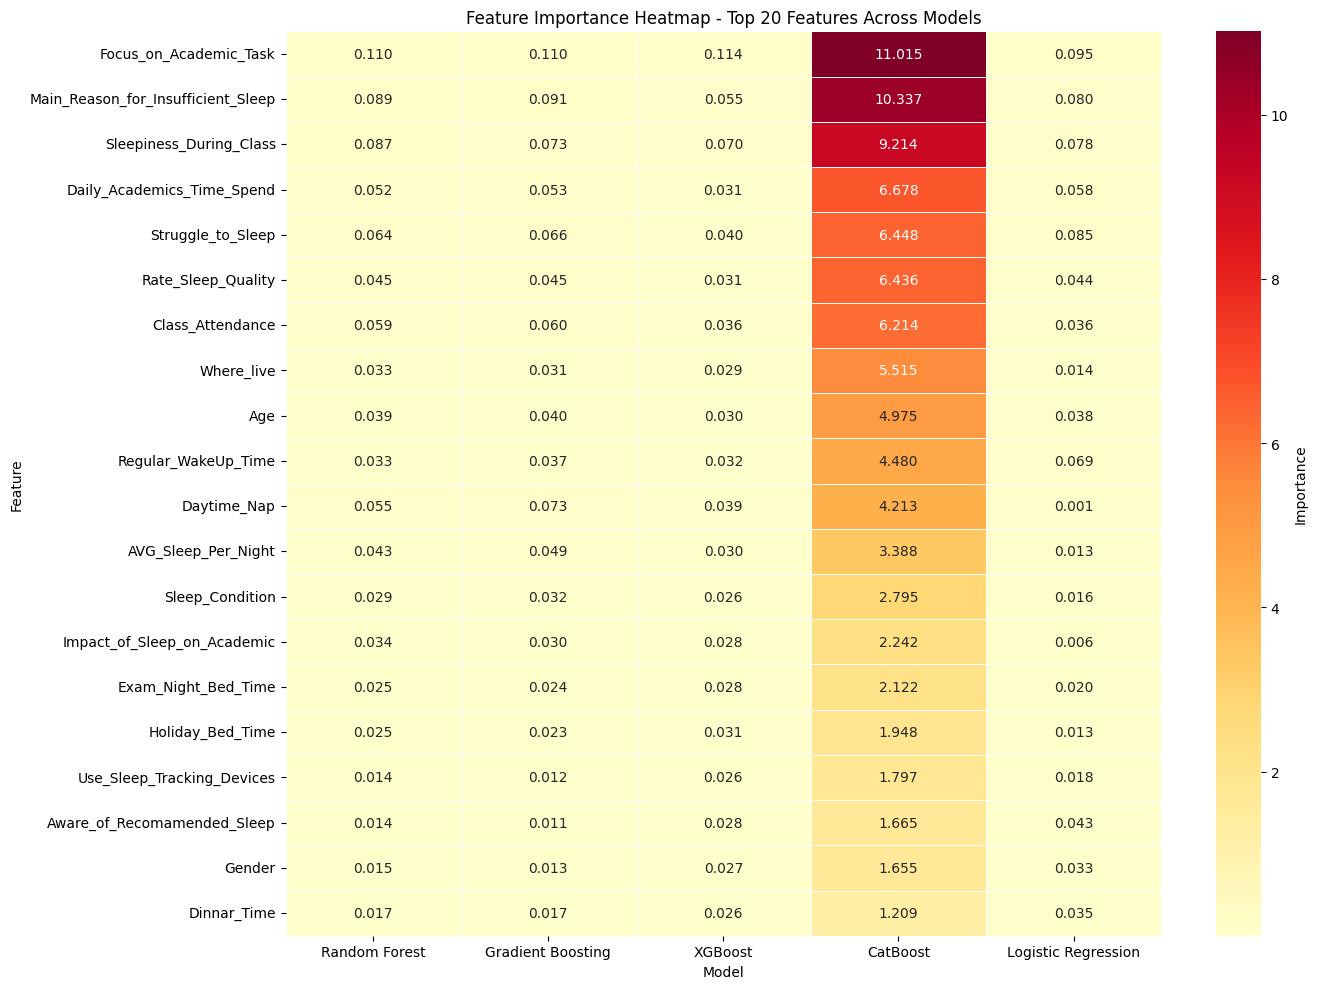


Figure saved to: ../images/feature_importance_5class_heatmap.png


In [60]:
# Heatmap of feature importance across all models
plt.figure(figsize=(14, 10))

# Get top 20 features by average importance
top_features = importance_df['Average'].sort_values(ascending=False).head(20).index
heatmap_data = importance_df.loc[top_features, models_to_plot]

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Importance'})
plt.title('Feature Importance Heatmap - Top 20 Features Across Models')
plt.xlabel('Model')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../images/feature_importance_5class_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to: ../images/feature_importance_5class_heatmap.png")

In [61]:
# Save feature importance to CSV
importance_df.to_csv('../results/feature_importance_5class_all_models.csv')
print("Feature importance saved to: ../results/feature_importance_5class_all_models.csv")

# Summary of most important features
print("\n" + "="*60)
print("FEATURE IMPORTANCE SUMMARY")
print("="*60)
print("\nTop 10 Most Influential Features (by average importance):")
for i, (feature, importance) in enumerate(importance_df['Average'].head(10).items(), 1):
    print(f"  {i}. {feature}: {importance:.4f}")

Feature importance saved to: ../results/feature_importance_5class_all_models.csv

FEATURE IMPORTANCE SUMMARY

Top 10 Most Influential Features (by average importance):
  1. Focus_on_Academic_Task: 2.2888
  2. Main_Reason_for_Insufficient_Sleep: 2.1304
  3. Sleepiness_During_Class: 1.9044
  4. Daily_Academics_Time_Spend: 1.3745
  5. Struggle_to_Sleep: 1.3405
  6. Rate_Sleep_Quality: 1.3201
  7. Class_Attendance: 1.2811
  8. Where_live: 1.1247
  9. Age: 1.0243
  10. Regular_WakeUp_Time: 0.9302


---
## 14. 📊 Model Performance Summary Table

Comprehensive comparison of all models with key metrics.

In [62]:
# ============================================================================
# COMPREHENSIVE MODEL COMPARISON TABLE
# ============================================================================

from sklearn.metrics import precision_score, recall_score

print("Creating comprehensive model comparison table...\n")

# Store results for all models
all_model_results = []

# ===== 1. GRADIENT BOOSTING =====
gb_acc = accuracy_score(y_test, y_pred_gb)
gb_prec = precision_score(y_test, y_pred_gb, average='macro')
gb_rec = recall_score(y_test, y_pred_gb, average='macro')
gb_f1 = f1_score(y_test, y_pred_gb, average='macro')
gb_roc = roc_auc_score(y_test, gb_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Gradient Boosting',
    'Accuracy': round(gb_acc, 4),
    'Precision': round(gb_prec, 4),
    'Recall': round(gb_rec, 4),
    'F1-Score': round(gb_f1, 4),
    'ROC-AUC': round(gb_roc, 4)
})

# ===== 2. XGBOOST =====
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_prec = precision_score(y_test, y_pred_xgb, average='macro')
xgb_rec = recall_score(y_test, y_pred_xgb, average='macro')
xgb_f1 = f1_score(y_test, y_pred_xgb, average='macro')
xgb_roc = roc_auc_score(y_test, xgb_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'XGBoost',
    'Accuracy': round(xgb_acc, 4),
    'Precision': round(xgb_prec, 4),
    'Recall': round(xgb_rec, 4),
    'F1-Score': round(xgb_f1, 4),
    'ROC-AUC': round(xgb_roc, 4)
})

# ===== 3. CATBOOST =====
cb_acc = accuracy_score(y_test, y_pred_cat)
cb_prec = precision_score(y_test, y_pred_cat, average='macro')
cb_rec = recall_score(y_test, y_pred_cat, average='macro')
cb_f1 = f1_score(y_test, y_pred_cat, average='macro')
cb_roc = roc_auc_score(y_test, catboost_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'CatBoost',
    'Accuracy': round(cb_acc, 4),
    'Precision': round(cb_prec, 4),
    'Recall': round(cb_rec, 4),
    'F1-Score': round(cb_f1, 4),
    'ROC-AUC': round(cb_roc, 4)
})

# ===== 4. RANDOM FOREST =====
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='macro')
rf_rec = recall_score(y_test, y_pred_rf, average='macro')
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')
rf_roc = roc_auc_score(y_test, rf_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Random Forest',
    'Accuracy': round(rf_acc, 4),
    'Precision': round(rf_prec, 4),
    'Recall': round(rf_rec, 4),
    'F1-Score': round(rf_f1, 4),
    'ROC-AUC': round(rf_roc, 4)
})

# ===== 5. LOGISTIC REGRESSION =====
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, average='macro')
lr_rec = recall_score(y_test, y_pred_lr, average='macro')
lr_f1 = f1_score(y_test, y_pred_lr, average='macro')
lr_roc = roc_auc_score(y_test, lr_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': round(lr_acc, 4),
    'Precision': round(lr_prec, 4),
    'Recall': round(lr_rec, 4),
    'F1-Score': round(lr_f1, 4),
    'ROC-AUC': round(lr_roc, 4)
})

# ===== 6. NEURAL NETWORK =====
ann_model.eval()
with torch.no_grad():
    outputs = ann_model(X_test_tensor)
    y_prob_ann = torch.softmax(outputs, dim=1).cpu().numpy()

ann_acc = accuracy_score(y_test, y_pred_ann)
ann_prec = precision_score(y_test, y_pred_ann, average='macro')
ann_rec = recall_score(y_test, y_pred_ann, average='macro')
ann_f1 = f1_score(y_test, y_pred_ann, average='macro')
ann_roc = roc_auc_score(y_test, y_prob_ann, multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Neural Network',
    'Accuracy': round(ann_acc, 4),
    'Precision': round(ann_prec, 4),
    'Recall': round(ann_rec, 4),
    'F1-Score': round(ann_f1, 4),
    'ROC-AUC': round(ann_roc, 4)
})

# Create DataFrame and sort by accuracy
final_comparison_df = pd.DataFrame(all_model_results)
final_comparison_df = final_comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

# Add rank
final_comparison_df.insert(0, 'Rank', range(1, len(final_comparison_df) + 1))

# Display table
print("=" * 95)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON - 5-CLASS CGPA PREDICTION")
print("=" * 95)
print(final_comparison_df.to_string(index=False))
print("=" * 95)

# Summary
best_model = final_comparison_df.iloc[0]['Model']
best_acc = final_comparison_df.iloc[0]['Accuracy']

print(f"\n🏆 Best Model: {best_model}")
print(f"📊 Best Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"📈 Models Compared: {len(final_comparison_df)}")
print("=" * 95)

# Save results
final_comparison_df.to_csv('../results/final_5class_model_comparison.csv', index=False)
print("\n✓ Results saved to: ../results/final_5class_model_comparison.csv")

Creating comprehensive model comparison table...

COMPREHENSIVE MODEL PERFORMANCE COMPARISON - 5-CLASS CGPA PREDICTION
 Rank               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
    1            CatBoost    0.4661     0.3927  0.3797    0.3731   0.7289
    2             XGBoost    0.4531     0.3739  0.3734    0.3711   0.7249
    3   Gradient Boosting    0.4479     0.3523  0.3581    0.3532   0.7267
    4       Random Forest    0.4427     0.3450  0.3529    0.3363   0.7162
    5 Logistic Regression    0.4141     0.3430  0.3454    0.3432   0.6648
    6      Neural Network    0.4036     0.3280  0.3314    0.3282   0.6928

🏆 Best Model: CatBoost
📊 Best Accuracy: 0.4661 (46.61%)
📈 Models Compared: 6

✓ Results saved to: ../results/final_5class_model_comparison.csv
